In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
from sklearn.metrics import average_precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [2]:
world = pd.read_csv('data/pop_worldometer_data.csv')

world.head()

world.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country (or dependency)  235 non-null    object 
 1   Population (2020)        235 non-null    int64  
 2   Yearly Change %          206 non-null    float64
 3   Net Change               235 non-null    int64  
 4   Density (P/Km²)          235 non-null    float64
 5   Land Area (Km²)          235 non-null    float64
 6   Migrants (net)           201 non-null    float64
 7   Fert. Rate               201 non-null    float64
 8   Med. Age                 201 non-null    float64
 9   Urban Pop %              222 non-null    float64
 10  World Share %            235 non-null    float64
dtypes: float64(8), int64(2), object(1)
memory usage: 20.3+ KB


In [3]:
world.describe()

,Population (2020),Yearly Change %,Net Change,Density (P/Km²),Land Area (Km²),Migrants (net),Fert. Rate,Med. Age,Urban Pop %,World Share %
count,2.350000e+02,206.000000,2.350000e+02,235.000000,2.350000e+02,201.000000,201.000000,201.000000,222.000000,235.000000
mean,3.316936e+07,1.330146,3.460878e+05,475.770213,5.535918e+05,6.283582,2.693035,30.606965,59.234234,0.425447
std,1.351374e+08,0.930457,1.128260e+06,2331.285935,1.687796e+06,123291.887548,1.264496,9.127965,24.230400,1.733723
min,8.010000e+02,0.000000,-3.838400e+05,0.000000,0.000000e+00,-653249.000000,1.100000,15.000000,0.000000,0.000000
25%,3.988760e+05,0.592500,4.240000e+02,37.000000,2.545000e+03,-10047.000000,1.700000,22.000000,43.000000,0.010000
50%,5.459642e+06,1.140000,3.917000e+04,95.000000,7.724000e+04,-852.000000,2.300000,30.000000,60.500000,0.070000
75%,2.057705e+07,1.957500,2.496600e+05,239.500000,4.038200e+05,9741.000000,3.600000,39.000000,79.000000,0.265000
max,1.439324e+09,3.840000,1.358663e+07,26337.000000,1.637687e+07,954806.000000,7.000000,48.000000,100.000000,18.470000


In [4]:
world['Yearly Change %'] = world.apply(lambda row: row['Net Change'] / row['Population (2020)'] * 100 if pd.isna(row['Net Change']) else row['Net Change'], axis=1)

# Fill missing values for other columns if necessary
world['Migrants (net)'] = world['Migrants (net)'].fillna(world['Migrants (net)'].mean())
world['Fert. Rate'] = world['Fert. Rate'].fillna(world['Fert. Rate'].mean())
world['Med. Age'] = world['Med. Age'].fillna(world['Med. Age'].mean())
world['Urban Pop %'] = world['Urban Pop %'].fillna(world['Urban Pop %'].mean())


<Axes: >

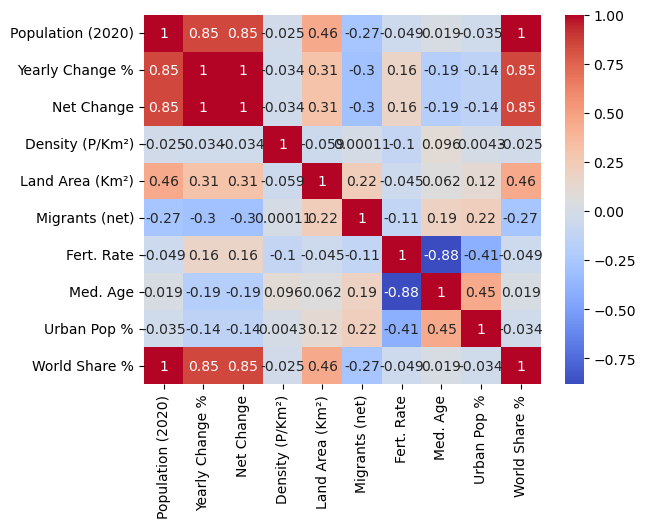

In [5]:

numeric_columns = world.select_dtypes(include=['number'])

#plot the heatmap using only the numeric columns
sns.heatmap(numeric_columns.corr(), annot=True, cmap='coolwarm')


In [6]:
import plotly.express as px
import pandas as pd
import geopandas as gpd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Preparing features and scaling them
features = world[['Population (2020)', 'Density (P/Km²)', 'Migrants (net)', 'Fert. Rate']].fillna(0)

scalar = StandardScaler()
scaled_features = scalar.fit_transform(features)

# KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=0)
world['cluster'] = kmeans.fit_predict(scaled_features)

# Read the world map from geopandas
world_map = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Merge world map with clustering data
merged = world_map.set_index('name').join(world.set_index('Country (or dependency)'))

# Convert merged data to a format Plotly can use for choropleth map
merged['cluster'] = merged['cluster'].astype(str)  # Ensure clusters are treated as strings for color
merged_map = merged.reset_index()

# Create the interactive map using Plotly
fig = px.choropleth(merged_map,
                    locations='name',  # Country name as location
                    color='cluster',  # Cluster as color
                    hover_name='name',
                    color_continuous_scale="Viridis",  # The same colormap as before
                    title="KMeans Clustering of Countries by Population, Density, Migrants, and Fertility Rate",
                    labels={'cluster': 'Cluster'},
                    locationmode="country names")

# Customize the map layout
fig.update_geos(showcoastlines=True, coastlinecolor="Black", showland=True, landcolor="lightgrey")

# Save the interactive map as an HTML file
fig.write_html("kmeans_clustering_map.html")

# Show the interactive map
fig.show()


In [7]:
# Check for missing values in relevant columns
world[['Fert. Rate', 'Yearly Change %']].isnull().sum()
# Check data types
world[['Yearly Change %', 'Fert. Rate']].dtypes

# Convert to numeric if needed
world['Yearly Change %'] = pd.to_numeric(world['Yearly Change %'], errors='coerce')
world['Fert. Rate'] = pd.to_numeric(world['Fert. Rate'], errors='coerce')


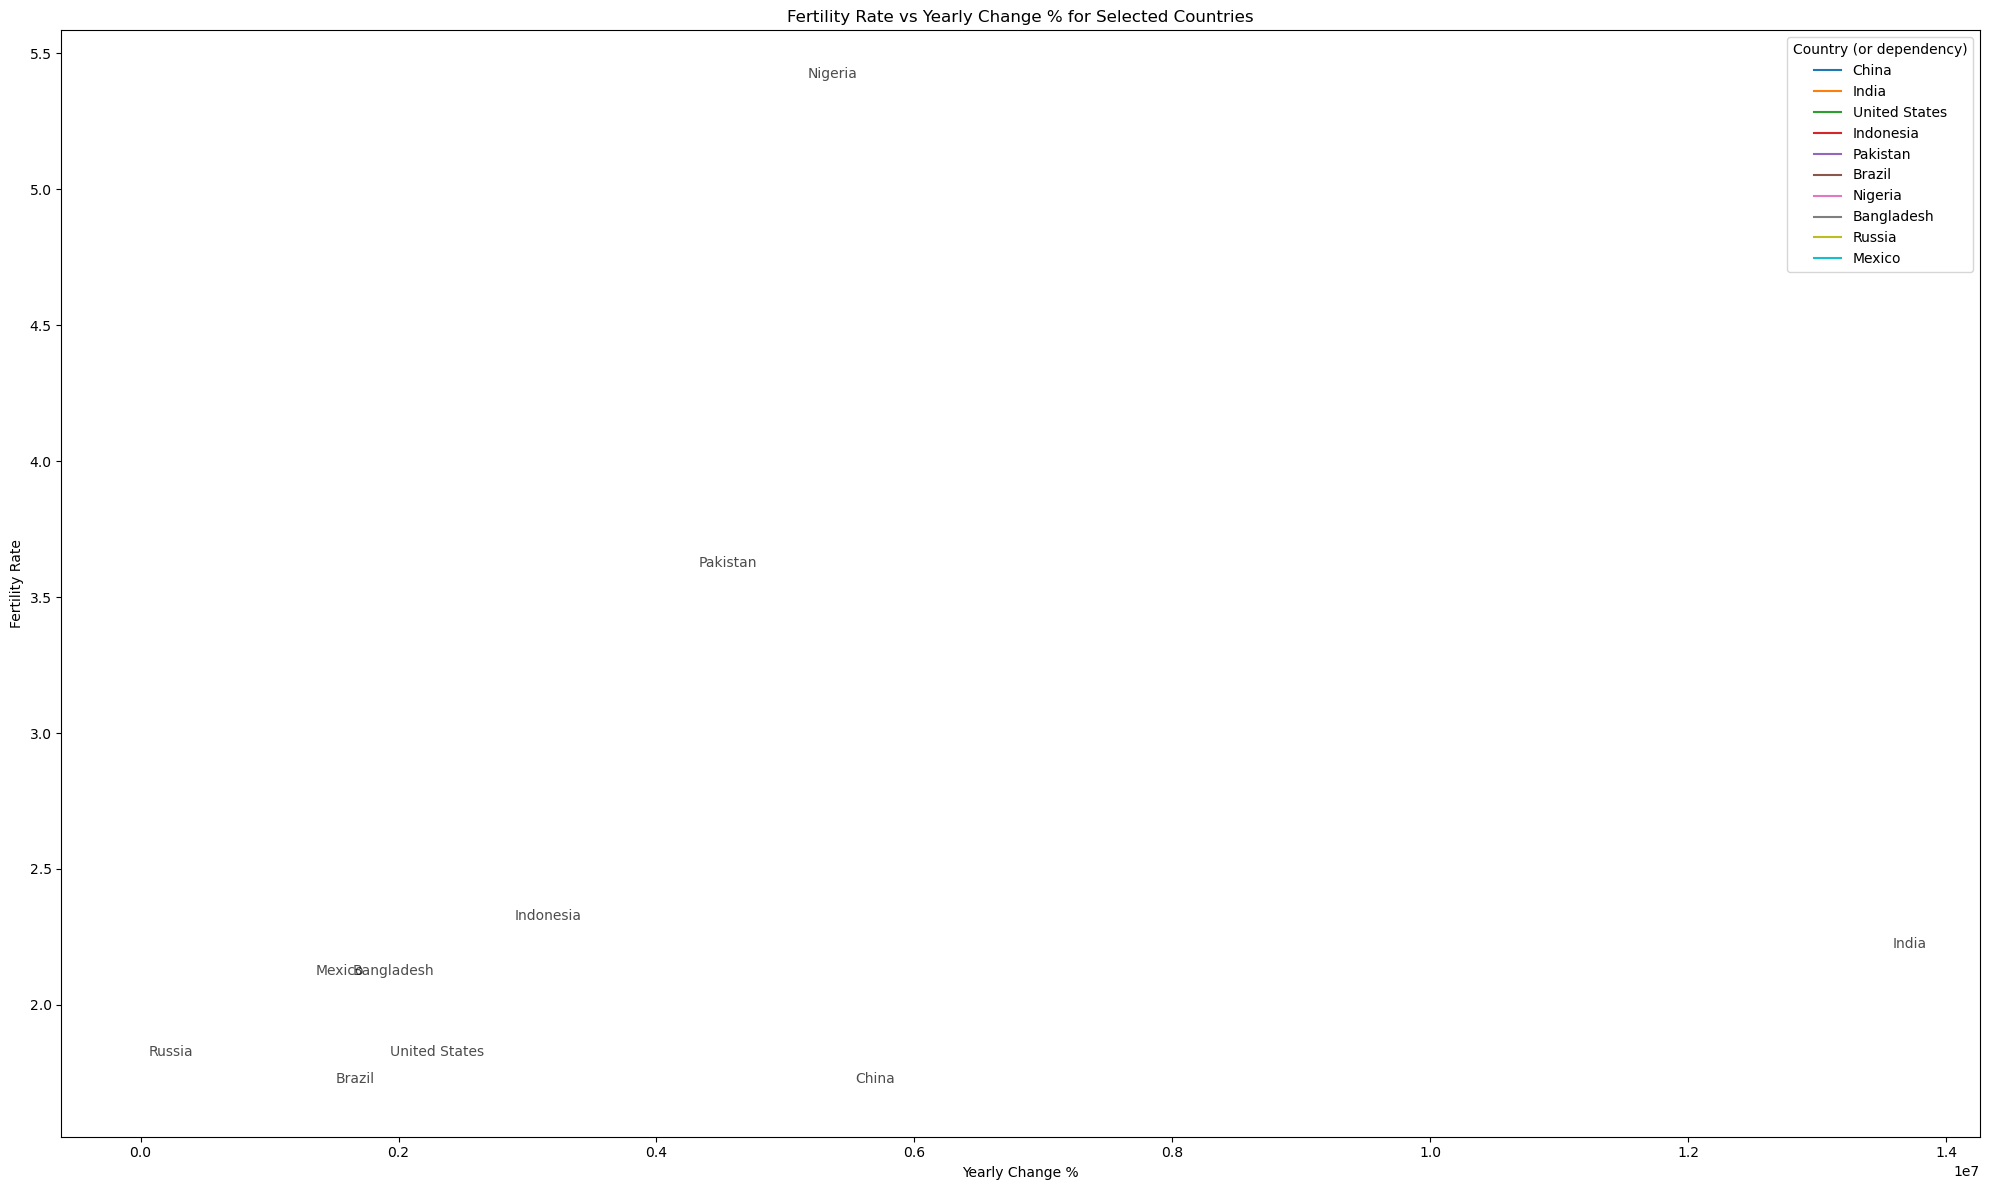

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for a few countries (optional)
sample_countries = world['Country (or dependency)'].unique()[:10]  # Adjust the number if needed
world_sample = world[world['Country (or dependency)'].isin(sample_countries)]

plt.figure(figsize=(20, 12))

# Plot the data with 'hue' to distinguish by country
sns.lineplot(x='Yearly Change %', y='Fert. Rate', hue='Country (or dependency)', data=world_sample)

# Adding titles and labels
plt.title('Fertility Rate vs Yearly Change % for Selected Countries')
plt.xlabel('Yearly Change %')
plt.ylabel('Fertility Rate')

# Adding country names to each line (for better visibility)
for country in sample_countries:
    country_data = world_sample[world_sample['Country (or dependency)'] == country]
    for x, y in zip(country_data['Yearly Change %'], country_data['Fert. Rate']):
        plt.text(x, y, country, fontsize=10, color='black', ha='left', va='bottom', alpha=0.7)

plt.tight_layout()
plt.savefig('fertility_rate_vs_yearly_change_with_names.png')
plt.show()


In [9]:
import plotly.express as px

# Create a choropleth map for World Population in 2020
fig = px.choropleth(world, 
                    locations="Country (or dependency)", 
                    color="Population (2020)", 
                    hover_name="Country (or dependency)", 
                    color_continuous_scale="Viridis", 
                    title="World Population in 2020", 
                    locationmode="country names")  # Ensures Plotly recognizes the country names

# Update the geos for map details
fig.update_geos(showcoastlines=True, coastlinecolor="Black", showland=True, landcolor="white")

# Save and display the map
fig.write_html("population_map.html")  # Save the interactive map as an HTML file
fig.show()


In [10]:
# Example: Predicting Urban Population %
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Select features for prediction
X = world[['Population (2020)', 'Net Change', 'Density (P/Km²)', 'Migrants (net)', 'Fert. Rate']]
y = world['Urban Pop %'].fillna(world['Urban Pop %'].mean())  # Fill NaNs in the target variable

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate the model
from sklearn.metrics import mean_squared_error, r2_score
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


Mean Squared Error: 501.1940676354331
R2 Score: 0.08952957515427418


In [11]:
import plotly.express as px

# Check and clean up country names (convert to matching format)
world_sorted = world[['Country (or dependency)', 'Fert. Rate']].dropna()
world_sorted = world_sorted.sort_values(by='Fert. Rate')

# To ensure compatibility with Plotly's choropleth, we use the 'locationmode' parameter
fig = px.choropleth(world_sorted, 
                    locations="Country (or dependency)", 
                    color="Fert. Rate",  
                    hover_name="Country (or dependency)",   
                    color_continuous_scale=px.colors.sequential.Plasma,
                    title="Fertility Rate by Country",
                    labels={'Fert. Rate': 'Fertility Rate (%)'},
                    locationmode="country names"  # This makes sure country names are recognized by Plotly
                    )

# Update the map layout and projection style
fig.update_geos(showcoastlines=True, coastlinecolor="Black", projection_type='orthographic') 
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0}, geo=dict(showland=True, landcolor="lightgray"))

# Show the map
fig.show()


In [12]:
fig = px.scatter(world,
                 x = 'Population (2020)',
                 y = 'Migrants (net)',
                 color = 'Migrants (net)',
                 hover_name= 'Country (or dependency)',
                 color_continuous_scale=px.colors.sequential.Plasma,
                 title = 'Population vs Net Migration',
                 labels={'Population (2020)': 'Population', 'Migrants (net)': 'Net Migration'},
                 template = 'plotly_dark')

# Customize the layout to improve the visual appeal
fig.update_layout(
    xaxis_title="Population (2020)",
    yaxis_title="Migrants (net)",
    margin={"r":1,"t":40,"l":50,"b":10},
    hovermode = 'closest',
    plot_bgcolor = 'black',
) 

fig.update_xaxes(showgrid= True, gridwidth=1, gridcolor='gray')
fig.update_yaxes(showgrid= True, gridwidth=1, gridcolor='gray')

fig.show()


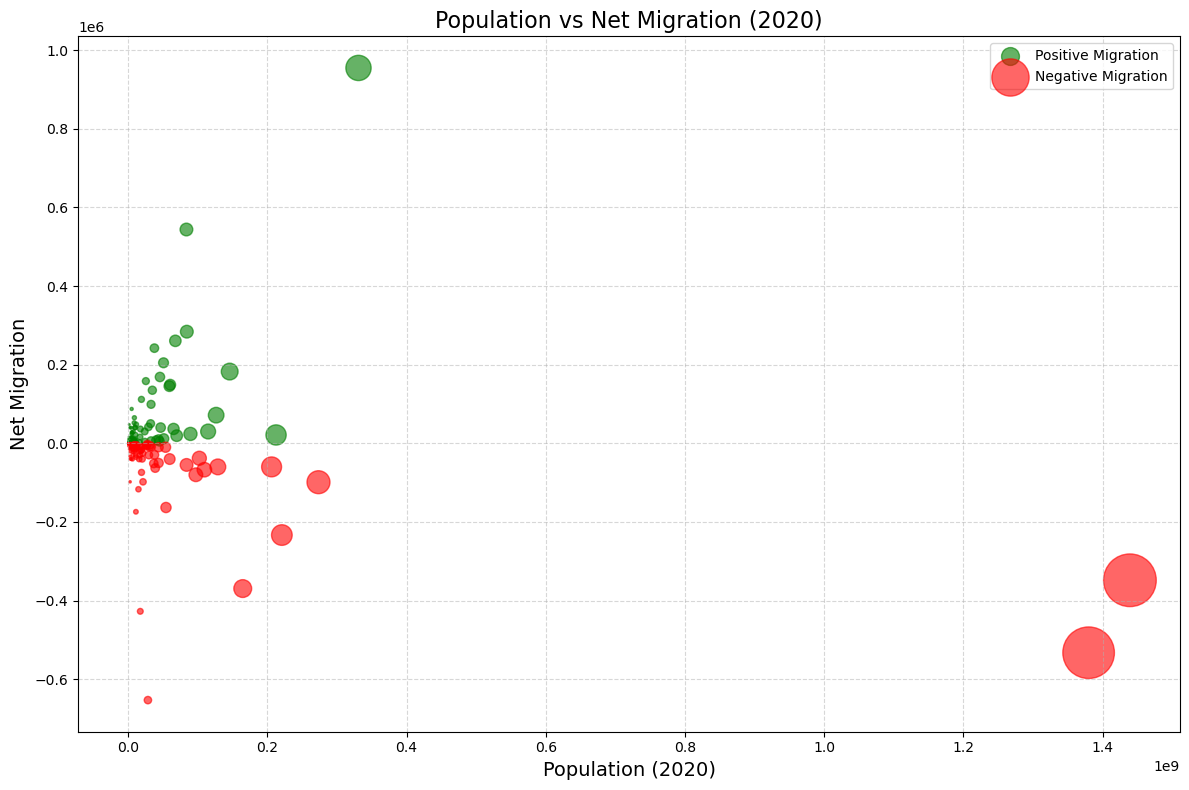

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the color palette (separate for positive and negative migration values)
positive_migration = world[world['Migrants (net)'] > 0]
negative_migration = world[world['Migrants (net)'] <= 0]

# Set the figure size
plt.figure(figsize=(12, 8))

# Plot positive migration (green color for inflow)
plt.scatter(positive_migration['Population (2020)'], 
            positive_migration['Migrants (net)'], 
            s=positive_migration['Population (2020)'] / 1000000,  # Scale bubble size by population
            color='green', alpha=0.6, label='Positive Migration')

# Plot negative migration (red color for outflow)
plt.scatter(negative_migration['Population (2020)'], 
            negative_migration['Migrants (net)'], 
            s=negative_migration['Population (2020)'] / 1000000,  # Scale bubble size by population
            color='red', alpha=0.6, label='Negative Migration')

# Add labels for the axes
plt.xlabel('Population (2020)', fontsize=14)
plt.ylabel('Net Migration', fontsize=14)

# Add a title
plt.title('Population vs Net Migration (2020)', fontsize=16)

# Add gridlines for better readability
plt.grid(True, linestyle='--', alpha=0.5)

# Add a legend
plt.legend()

# Adjust layout for better presentation
plt.tight_layout()

# Show the plot
plt.show()


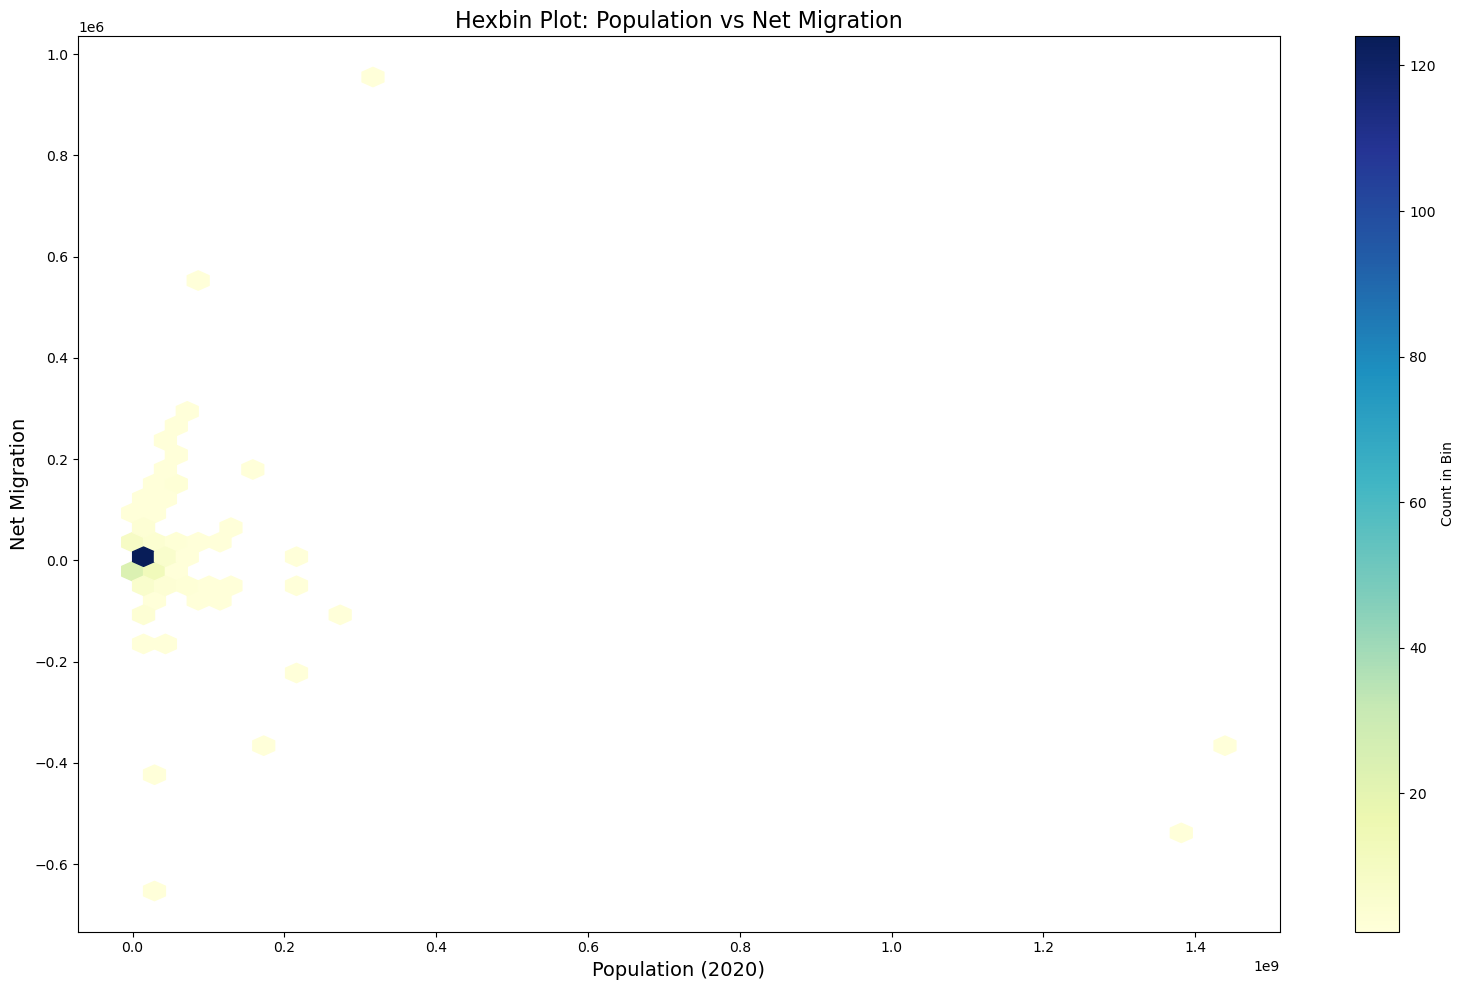

In [14]:
import matplotlib.pyplot as plt

# Define the figure size
plt.figure(figsize=(16, 10))

# Hexbin plot
plt.hexbin(world['Population (2020)'], world['Migrants (net)'], 
           gridsize=50, cmap='YlGnBu', mincnt=1)

# Add color bar
plt.colorbar(label='Count in Bin')

# Add labels for the axes
plt.xlabel('Population (2020)', fontsize=14)
plt.ylabel('Net Migration', fontsize=14)

# Add a title
plt.title('Hexbin Plot: Population vs Net Migration', fontsize=16)

# Show the plot
plt.tight_layout()
plt.show()


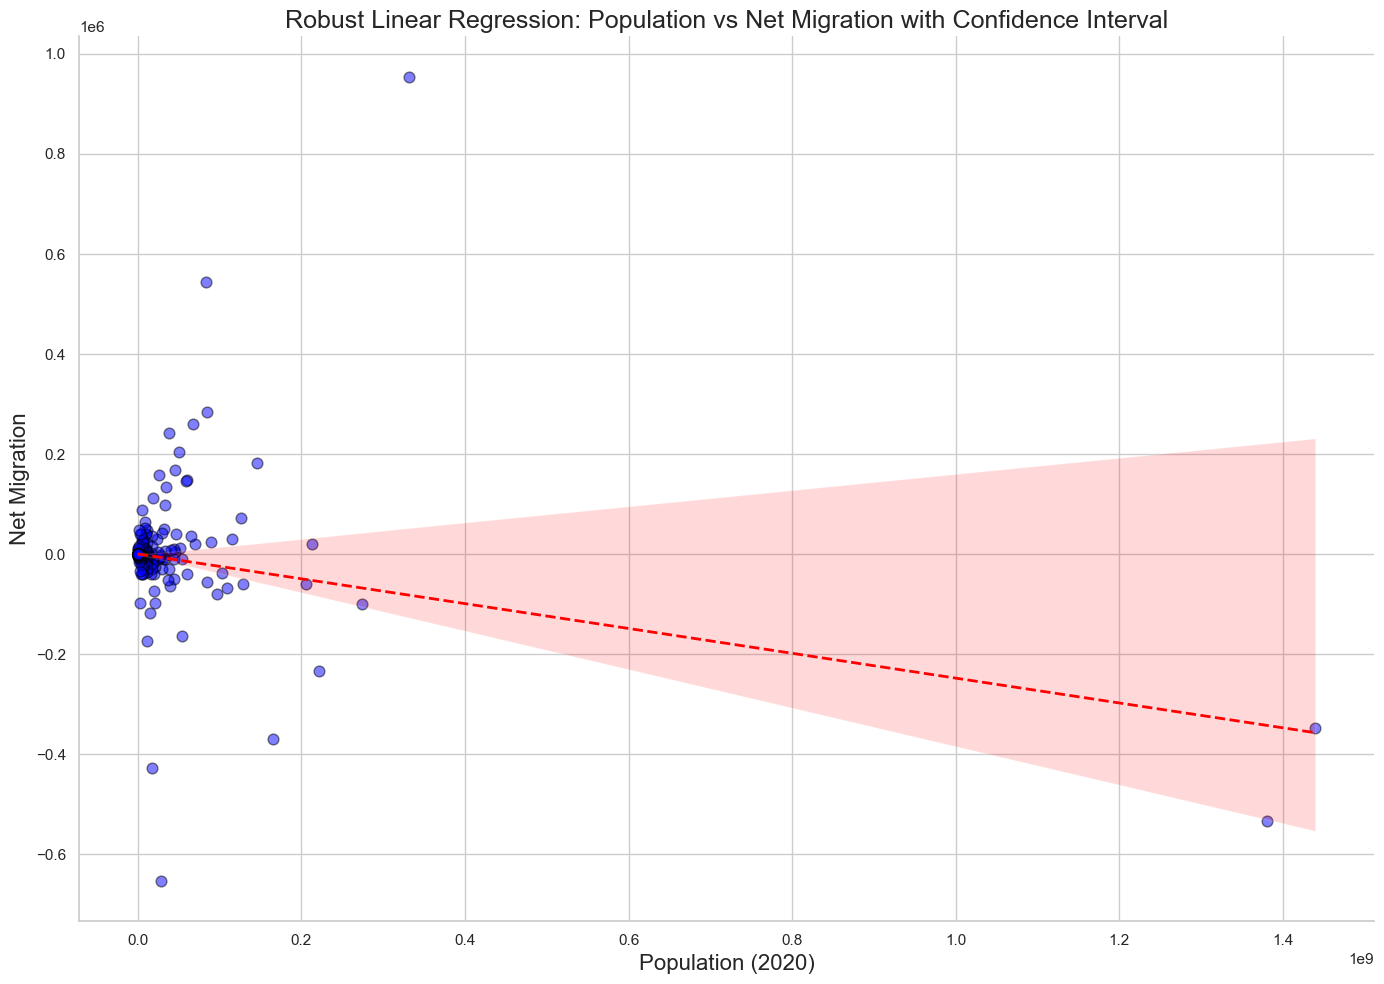

In [19]:

# Set the figure size
plt.figure(figsize=(14, 10))

# Use a seaborn style for better aesthetics
sns.set(style="whitegrid")

# Plot the data with robust regression line and confidence interval
sns.regplot(x='Population (2020)', y='Migrants (net)', data=world, 
            scatter_kws={'color': 'blue', 'alpha': 0.5, 's': 60, 'edgecolor': 'black'},  # Adding edgecolor for scatter points
            line_kws={'color': 'red', 'lw': 2, 'linestyle': '--'},  # Customize line style
            ci=95,  # Show 95% confidence interval for regression line
            robust=True)  # Apply robust regression

# Add labels for the axes
plt.xlabel('Population (2020)', fontsize=16)
plt.ylabel('Net Migration', fontsize=16)

# Add a title
plt.title('Robust Linear Regression: Population vs Net Migration with Confidence Interval', fontsize=18)

# Show the grid and remove top and right borders for cleaner look
sns.despine()

# Show the plot
plt.tight_layout()
plt.show()


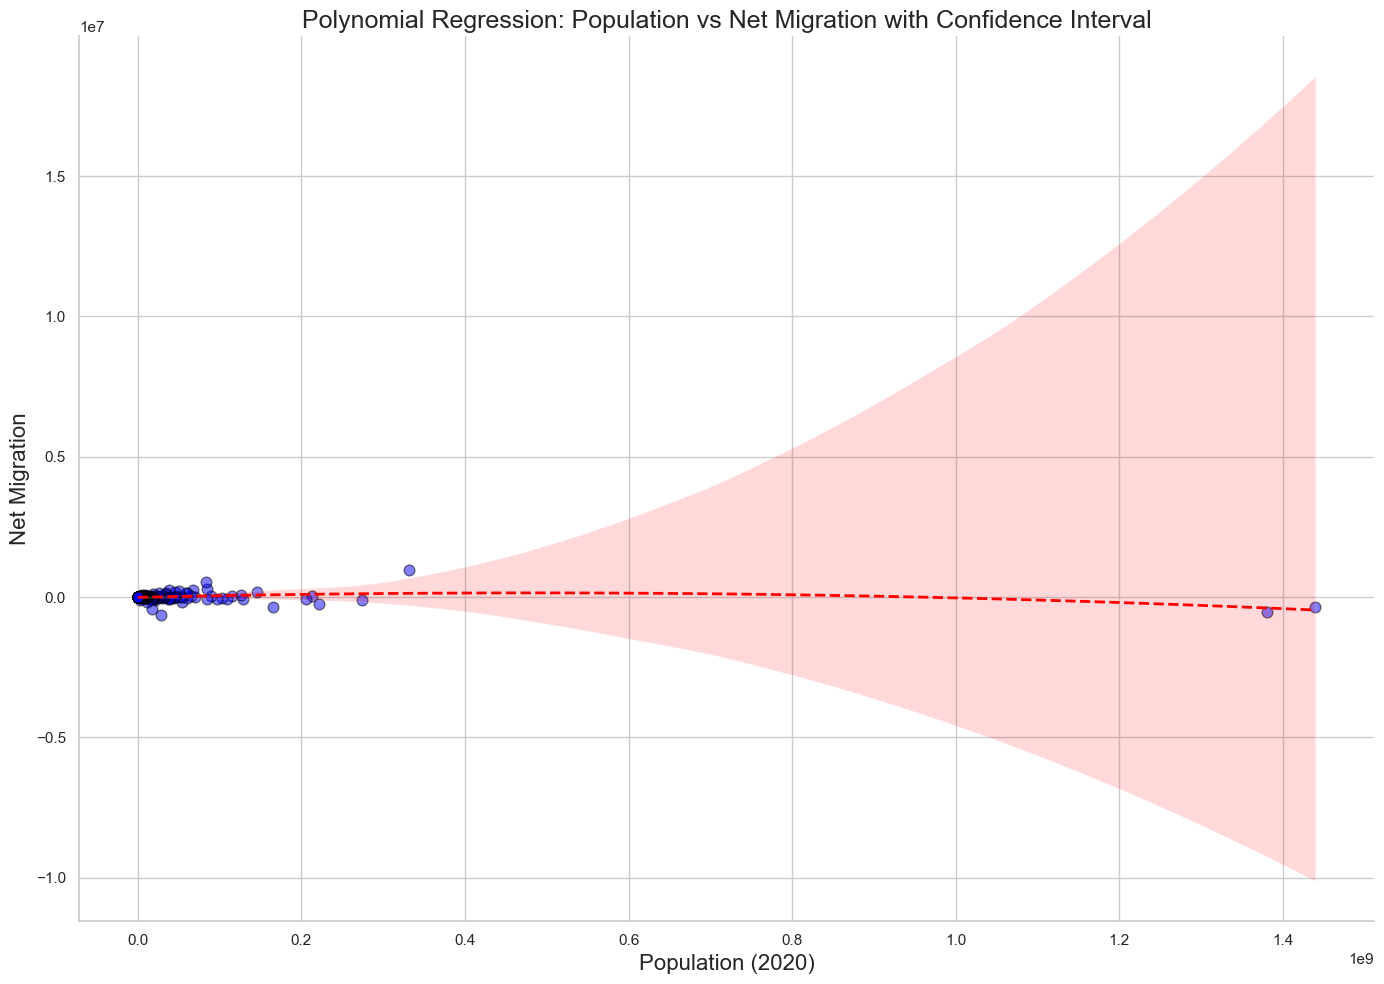

In [20]:
# Set the figure size
plt.figure(figsize=(14, 10))

# Use a seaborn style for better aesthetics
sns.set(style="whitegrid")

# Plot the data with polynomial regression line and confidence interval
sns.regplot(x='Population (2020)', y='Migrants (net)', data=world, 
            scatter_kws={'color': 'blue', 'alpha': 0.5, 's': 60, 'edgecolor': 'black'},  # Adding edgecolor for scatter points
            line_kws={'color': 'red', 'lw': 2, 'linestyle': '--'},  # Customize line style
            ci=95,  # Show 95% confidence interval for regression line
            order=2)  # Apply polynomial regression (2nd order)

# Add labels for the axes
plt.xlabel('Population (2020)', fontsize=16)
plt.ylabel('Net Migration', fontsize=16)

# Add a title
plt.title('Polynomial Regression: Population vs Net Migration with Confidence Interval', fontsize=18)

# Show the grid and remove top and right borders for cleaner look
sns.despine()

# Show the plot
plt.tight_layout()
plt.show()


/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_34861/1799054923.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




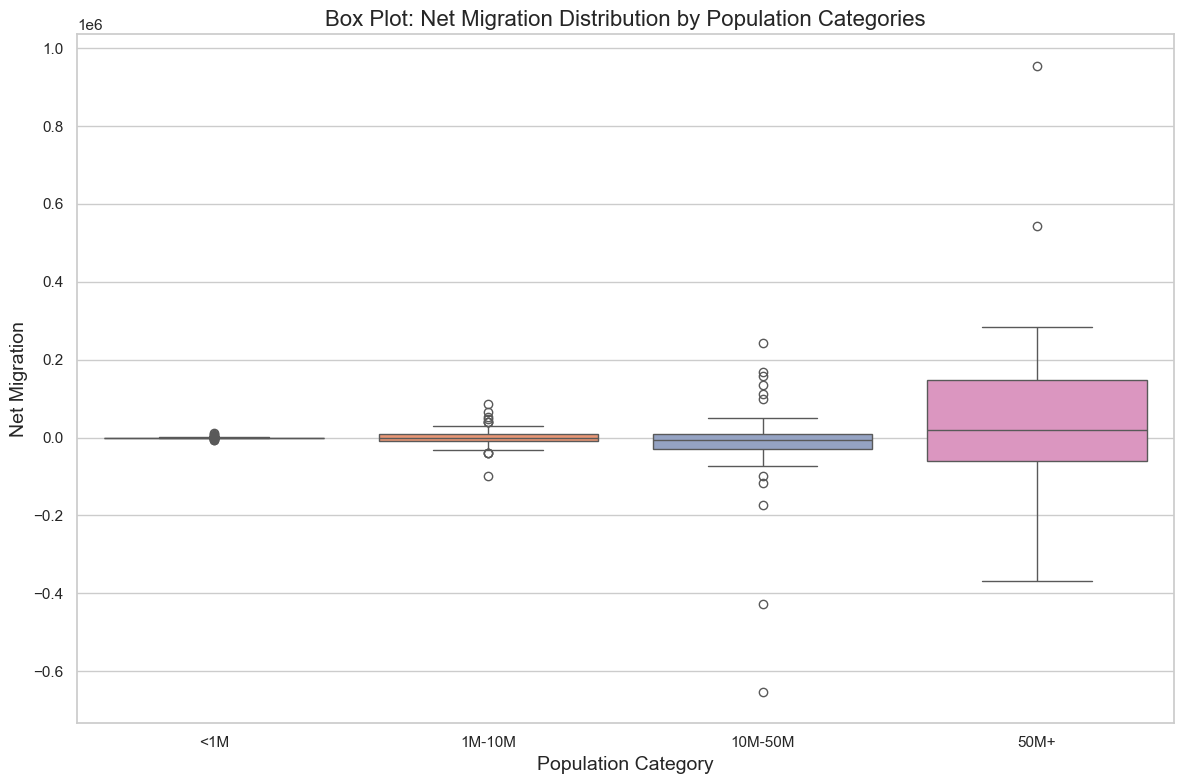

In [18]:
import seaborn as sns

# Define population ranges (optional categorization)
bins = [0, 1e6, 1e7, 5e7, 1e9]  # Example bins for population categories
labels = ['<1M', '1M-10M', '10M-50M', '50M+']  # Categories

# Create a new column to categorize population
world['Population Category'] = pd.cut(world['Population (2020)'], bins=bins, labels=labels)

# Set the figure size
plt.figure(figsize=(12, 8))

# Box plot for migration distribution by population category
sns.boxplot(x='Population Category', y='Migrants (net)', data=world, 
            palette='Set2')

# Add labels for the axes
plt.xlabel('Population Category', fontsize=14)
plt.ylabel('Net Migration', fontsize=14)

# Add a title
plt.title('Box Plot: Net Migration Distribution by Population Categories', fontsize=16)

# Show the plot
plt.tight_layout()
plt.show()
